Goal: Build an end‑to‑end segmentation workflow on a customer dataset by combining scaling → PCA (dimensionality reduction) → clustering. You’ll choose hyperparameters (PCA components & number of clusters), visualize in 2D, evaluate quality (silhouette/CH/DB), and create actionable profiles.

In [1]:
# pip install pandas numpy scikit-learn matplotlib seaborn joblib
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA
import joblib
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

1) Load data (or synthesize so every cell runs)
Expected columns (numeric): Annual_Spend, Num_Orders, Avg_Basket, RecencyDays, ReturnsRate% (+ any others).
If your CSV isn’t ready, this creates a realistic synthetic dataset.

In [2]:
CSV_PATH = Path('customers.csv')
if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
else:
    n=900
    df = pd.DataFrame({
        'Annual_Spend':  np.r_[np.random.normal(450,90,300),  np.random.normal(1250,160,300), np.random.normal(2300,260,300)].clip(20),
        'Num_Orders':    np.r_[np.random.poisson(6,300),      np.random.poisson(16,300),      np.random.poisson(30,300)],
        'Avg_Basket':    np.r_[np.random.normal(60,10,300),   np.random.normal(90,12,300),    np.random.normal(120,18,300)],
        'RecencyDays':   np.r_[np.random.gamma(3,30,300),     np.random.gamma(2,25,300),      np.random.gamma(1.5,20,300)],
        'ReturnsRate%':  np.r_[np.random.beta(2,20,300),      np.random.beta(2,10,300),       np.random.beta(2,6,300)]*100
    })
df.head()

,Annual_Spend,Num_Orders,Avg_Basket,RecencyDays,ReturnsRate%
0,608.764711,9,46.898027,134.348763,6.346070
1,486.014149,9,70.791306,135.010842,6.321603
2,538.086419,4,58.972373,71.973583,3.110206
3,651.680388,9,58.176857,59.515691,22.635643
4,618.080219,4,40.007324,42.719274,10.914375


Select features (start with numeric only; you can add categoricals later via one‑hot):

In [3]:
num_cols = df.select_dtypes(include='number').columns.tolist()
X = df[num_cols].copy()
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Annual_Spend,900.0,1318.545754,768.397839,200.466652,511.898603,1229.107123,2096.438853,2974.550393
Num_Orders,900.0,17.271111,10.642949,0.000000,8.000000,15.000000,26.000000,48.000000
Avg_Basket,900.0,89.997868,28.277338,35.547725,66.207814,88.885405,111.030834,172.654493
RecencyDays,900.0,57.357023,48.547918,0.224343,21.853447,42.691802,79.296445,293.557051
ReturnsRate%,900.0,16.262855,11.991000,0.228728,7.509453,13.142610,22.312316,74.038861


2) Minimal cleaning (impute/winsorize) & scale

In [4]:
# (optional) winsorize extreme outliers to stabilize PCA/k-means
def winsorize(s, p=0.01):
    lo, hi = s.quantile(p), s.quantile(1-p)
    return s.clip(lo, hi)

X_w = X.apply(winsorize, axis=0)

pre = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), num_cols)
])
Xs = pre.fit_transform(X_w)
Xs.shape

(900, 5)

3) PCA exploration — how many components?

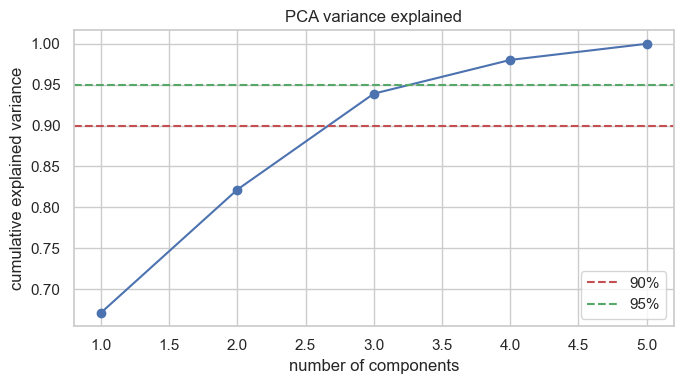

4

In [5]:
pca_full = PCA(n_components=None, random_state=0).fit(Xs)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(cumvar)+1), cumvar, marker='o')
plt.axhline(0.90, color='r', ls='--', label='90%')
plt.axhline(0.95, color='g', ls='--', label='95%')
plt.xlabel('number of components'); plt.ylabel('cumulative explained variance')
plt.title('PCA variance explained'); plt.legend(); plt.tight_layout(); plt.show()

# Choose a compact dimensionality (e.g., keep 90–95% variance)
n_comp = int(np.argmax(cumvar >= 0.95) + 1)
n_comp

Project to PCA space

In [6]:
pca = PCA(n_components=n_comp, random_state=0).fit(Xs)
Z = pca.transform(Xs)     # low-D features for clustering
Z.shape, pca.explained_variance_ratio_.sum()

((900, 4), np.float64(0.9802557663914381))

4) Choose k (clusters): silhouette & elbow

In [7]:
def try_k_values(Z, k_list):
    rows = []
    for k in k_list:
        km = KMeans(n_clusters=k, n_init='auto', random_state=0).fit(Z)
        labels = km.labels_
        sil = silhouette_score(Z, labels)
        ch  = calinski_harabasz_score(Z, labels)
        db  = davies_bouldin_score(Z, labels)
        rows.append((k, sil, ch, db, km.inertia_))
    return pd.DataFrame(rows, columns=['k','silhouette','calinski_harabasz','davies_bouldin','inertia'])

k_grid = list(range(2, 11))
scan = try_k_values(Z, k_grid)
scan

,k,silhouette,calinski_harabasz,davies_bouldin,inertia
0,2,0.435925,912.747044,0.883092,2187.659362
1,3,0.360924,814.582677,1.063631,1566.327555
2,4,0.353005,718.538298,1.077422,1295.180221
3,5,0.355624,736.958525,1.002190,1027.361577
4,6,0.331692,653.676209,1.118281,947.431027
5,7,0.276730,586.992999,1.222261,892.295792
6,8,0.290772,609.258259,1.209164,763.019834
7,9,0.284438,595.107620,1.169979,695.405553
8,10,0.269272,558.075296,1.224799,663.984165


Plot:

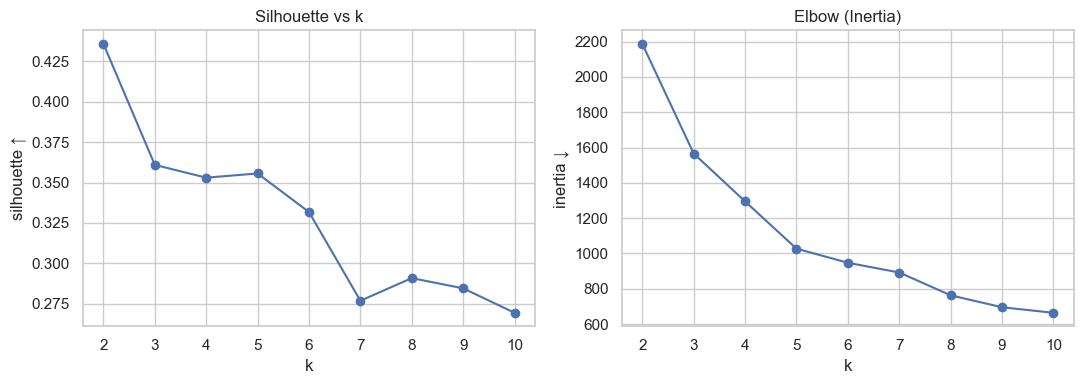

2

In [8]:
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(scan['k'], scan['silhouette'], marker='o'); ax[0].set_title('Silhouette vs k'); ax[0].set_xlabel('k'); ax[0].set_ylabel('silhouette ↑')
ax[1].plot(scan['k'], scan['inertia'],   marker='o'); ax[1].set_title('Elbow (Inertia)'); ax[1].set_xlabel('k'); ax[1].set_ylabel('inertia ↓')
plt.tight_layout(); plt.show()

best_k = int(scan.loc[scan['silhouette'].idxmax(), 'k'])
best_k

5) Final pipeline (scaler → PCA → k‑Means)

Keeps work reproducible and avoids leakage if you later split data.

In [9]:
pipe = Pipeline([
    ('pre', pre),
    ('pca', PCA(n_components=n_comp, random_state=0)),
    ('km',  KMeans(n_clusters=best_k, n_init='auto', random_state=0))
]).fit(X_w)

labels = pipe.named_steps['km'].labels_
df_seg = df.copy()
df_seg['cluster'] = labels
df_seg['cluster'].value_counts().sort_index()

cluster
0    574
1    326
Name: count, dtype: int64

Quality metrics

In [10]:
Z_final = pipe.named_steps['pca'].transform(pre.transform(X_w))
print("Silhouette:", round(silhouette_score(Z_final, labels), 3))
print("Calinski-Harabasz:", round(calinski_harabasz_score(Z_final, labels), 1))
print("Davies-Bouldin:", round(davies_bouldin_score(Z_final, labels), 3))

Silhouette: 0.436
Calinski-Harabasz: 912.7
Davies-Bouldin: 0.883


6) Visualize clusters in 2D
Use a separate PCA(2) for plotting (purely for visuals).

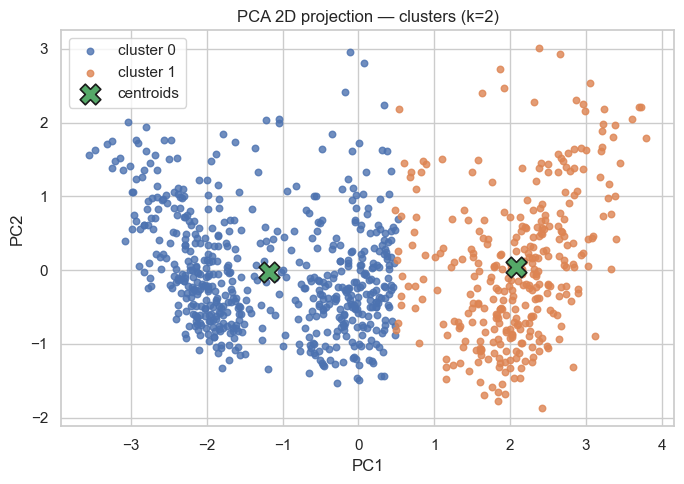

In [11]:
pca2 = PCA(n_components=2, random_state=0).fit(Xs)
Z2 = pca2.transform(Xs)
centroids2 = pca2.transform(pipe.named_steps['pca'].inverse_transform(pipe.named_steps['km'].cluster_centers_))

plt.figure(figsize=(7,5))
for c in sorted(df_seg['cluster'].unique()):
    idx = (df_seg['cluster']==c)
    plt.scatter(Z2[idx,0], Z2[idx,1], s=22, alpha=0.8, label=f'cluster {c}')
plt.scatter(centroids2[:,0], centroids2[:,1], marker='X', s=220, edgecolor='k', linewidth=1.2, label='centroids')
plt.title(f'PCA 2D projection — clusters (k={best_k})')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.tight_layout(); plt.show()

Optional) Silhouette plot

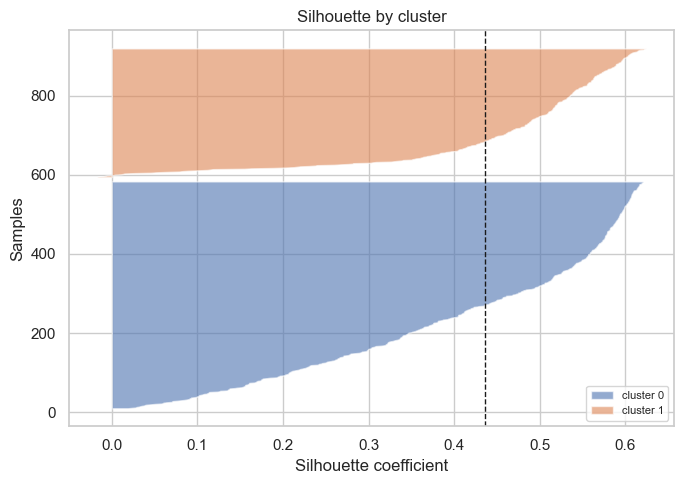

In [12]:
sil_vals = silhouette_samples(Z_final, labels)
y_lower = 10
plt.figure(figsize=(7,5))
for c in sorted(np.unique(labels)):
    sv = np.sort(sil_vals[labels==c])
    y_upper = y_lower + len(sv)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, sv, alpha=0.6, label=f'cluster {c}')
    y_lower = y_upper + 10
plt.axvline(np.mean(sil_vals), color='k', ls='--', lw=1)
plt.xlabel('Silhouette coefficient'); plt.ylabel('Samples'); plt.title('Silhouette by cluster')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

7) Cluster profiling (make it actionable)
Per‑cluster means on original scale + sizes; also a z‑score heatmap to see which features dominate.

In [13]:
profile_mean = (df_seg.groupby('cluster')[num_cols].mean().round(2)).assign(count=df_seg['cluster'].value_counts().sort_index())
profile_median = df_seg.groupby('cluster')[num_cols].median().round(2)
profile_mean

,Annual_Spend,Num_Orders,Avg_Basket,RecencyDays,ReturnsRate%,count
cluster,,,,,,
0,819.43,10.62,73.67,73.57,11.87,574
1,2197.36,28.99,118.74,28.81,24.00,326


Z‑score heatmap (feature strength by cluster)

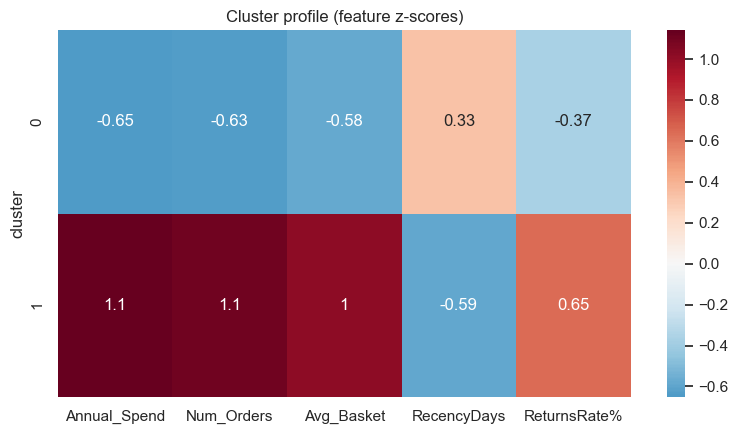

In [14]:
Xz = pd.DataFrame(StandardScaler().fit_transform(X), columns=num_cols)
Xz['cluster'] = labels
heat = Xz.groupby('cluster')[num_cols].mean().round(2)
plt.figure(figsize=(8,4.5))
sns.heatmap(heat, annot=True, cmap='RdBu_r', center=0)
plt.title('Cluster profile (feature z-scores)'); plt.tight_layout(); plt.show()

Write 1‑line “personas” (example—edit using your table):

Cluster 0: High Annual_Spend & Num_Orders, low RecencyDays → Loyal High‑Value

Cluster 1: Low spend, high RecencyDays → Lapsed/At‑Risk

Cluster 2: Mid spend, higher ReturnsRate% → Return‑Prone

8) Save artifacts

In [15]:
df_seg.to_csv('customers_with_clusters.csv', index=False)
profile_mean.to_csv('cluster_profile_summary.csv')
joblib.dump(pipe, 'pca_kmeans_pipeline.joblib')
['customers_with_clusters.csv', 'cluster_profile_summary.csv', 'pca_kmeans_pipeline.joblib']

['customers_with_clusters.csv',
 'cluster_profile_summary.csv',
 'pca_kmeans_pipeline.joblib']

9) (Optional) Robustness checks
Stability across seeds

In [16]:
seeds = [0,1,2,7,13,21,42]
sil_list = []
for s in seeds:
    mdl = Pipeline([('pre', pre), ('pca', PCA(n_components=n_comp, random_state=0)),
                    ('km', KMeans(n_clusters=best_k, n_init='auto', random_state=s))]).fit(X_w)
    Zf = mdl.named_steps['pca'].transform(pre.transform(X_w))
    sil_list.append(silhouette_score(Zf, mdl.named_steps['km'].labels_))
np.mean(sil_list), np.std(sil_list)

(np.float64(0.4281283120186953), np.float64(0.006770625180811842))